<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="https://mng.bz/lZ5B">Build a Reasoning Model (From Scratch)</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/reasoning-from-scratch">https://github.com/rasbt/reasoning-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="https://mng.bz/lZ5B"><img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# Chapter 8: Exercise Solutions

Packages that are being used in this notebook:

In [ ]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

&nbsp;
## Exercise 8.1: Training and validation set lengths      

- The following cells recreate the end of chapter section 8.4.3 and compute the training and validation length statistics using reusable helpers from `reasoning_from_scratch.ch08`
- If you still have the chapter 8 notebook open, you could also ignore the code below and just add excute the following:

```python
print("Training stats:")
compute_length(train_examples)

print("Validation stats:")
compute_length(val_examples)
```

In [9]:
import random

from reasoning_from_scratch.ch08 import (
    build_examples,
    compute_length,
    filter_examples_by_max_len,
    load_distill_data,
    load_reasoning_tokenizer,
)

In [10]:
math_train = load_distill_data(partition="deepseek-r1-math-train")
tokenizer = load_reasoning_tokenizer()

examples, skipped = build_examples(math_train, tokenizer)
print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

compute_length(examples)

filtered_examples = filter_examples_by_max_len(examples, max_len=2048)
compute_length(filtered_examples)

deepseek-r1-math-train.json: 107538.0 KB (cached)
✓ qwen3/tokenizer-reasoning.json already up-to-date
Number of examples: 12000
Number of skipped examples: 0
Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)
Original: 12000
Filtered: 6695
Removed: 5305
Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


In [11]:
rng = random.Random(123)
rng.shuffle(filtered_examples)

train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]

In [12]:
print("Training stats:")
compute_length(train_examples)

Training stats:
Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [13]:
print("Validation stats:")
compute_length(val_examples)

Validation stats:
Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


- As we can see, the average token length (1180 versus 1106) is fairly similar, and the datasets should be relatively balanced
- As a bonus, we can also plot histograms to visualize the distributions

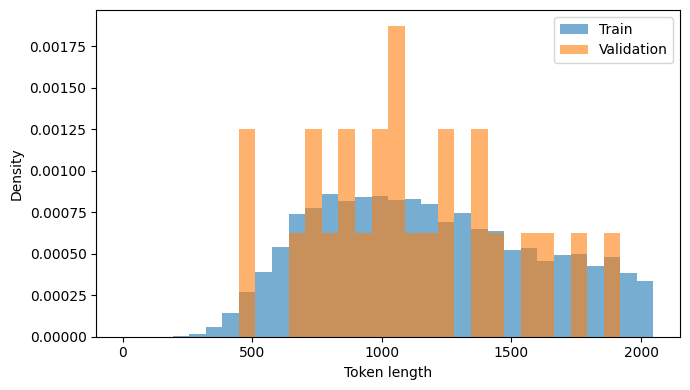

In [7]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("1.pdf")
plt.show()

- There are much fewer validation samples, which is why the validation histogram seems a bit jagged, but as we can see, it has a good distribution coverage

&nbsp;
## Exercise 8.2: Distilling without `<think>` tokens

- To replicate the runs without `<think></think>` tokens in the script execution command:

```bash
uv run distill.py \
--data_path deepseek-r1-math-train.json \
--validation_size 25 \
--epochs 3 \
--lr 1e-5 \
--max_seq_len 2048 \
--grad_clip 1.0
```

- Then, for the evaluation, we use the `base` instead of `reasoning` model:

```bash
uv run evaluate_math500.py \
--dataset_size 500 \
--which_model base \
--max_new_tokens 4096 \
--checkpoint_path run_11/checkpoints/distill/qwen3-0.6B-distill-step05746-epoch1.pth
```

- The new results (without think tokens) are shown first, with corresponding think-token results in parentheses

| Teacher data                      | Epoch | MATH-500 Acc  | Final val loss       |
|-----------------------------------|------:|--------------:|---------------------:|
| Base (chapter 3)                  |     - | 15.2%         |              -       |
| Reasoning (chapter 3)             |     - | 48.2%         |              -       |
| DeepSeek R1 distillation data     |     1 | 31.8% (30.6%) | 0.5436   (0.5404)    |
| DeepSeek R1 distillation data     |     2 | 31.8% (32.4%) | 0.5349   (0.5339)    |
| DeepSeek R1 distillation data     |     3 | 30.2% (33.6%) | 0.5343   (0.5306)    |
| Qwen3 235B A22B distillation data |     1 | 44.8% (45.0%) | 0.4043   (0.3130)    |
| Qwen3 235B A22B distillation data |     2 | 39.4% (43.8%) | 0.3963   (0.3087)    |
| Qwen3 235B A22B distillation data |     3 | 39.8% (44.2%) | 0.3948   (0.3078)    |

- Interestingly, the Qwen3 model has a lower validation loss when `<think></think>` tokens are omitted, but this doesn't translate into better modeling performance
- As we can see, the omission of `<think></think>` makes the results slightly worse in almost all cases